#  Deteksi Penyakit Daun Kentang dengan CNN
## Final Project Machine Learning - Kelompok 6

**Anggota Kelompok:**
- 5025241135 - Farikh Muhammad Fauzan
- 5025241138 - William Hans Chandra
- 5025241140 - Brave Juliada
- 5025241185 - Muhammad Nawfal Alfanni D

---

### Deskripsi Proyek

Proyek ini menggunakan **Convolutional Neural Network (CNN)** untuk mengidentifikasi kondisi daun kentang berdasarkan gambar. Model diklasifikasikan ke dalam tiga kategori:

| Kelas | Deskripsi |
|---|---|
| `Potato___Early_blight` | Penyakit bercak daun awal (*Alternaria solani*) |
| `Potato___Late_blight` | Penyakit bercak daun lanjut (*Phytophthora infestans*) |
| `Potato___healthy` | Daun kentang sehat |

Dataset yang digunakan adalah **PlantVillage** dari Kaggle dengan total **1.721 gambar** dan pembagian 80:20 untuk training dan validasi.

---

## Cell 1: Instalasi Library `kagglehub`

Cell ini menginstal library `kagglehub` yang dibutuhkan untuk mengunduh dataset langsung dari platform Kaggle.

- **`!pip install kagglehub`** → Perintah `!` digunakan di Google Colab untuk menjalankan perintah shell. `pip install` adalah perintah untuk menginstal paket Python.
- **`kagglehub`** → Library resmi dari Kaggle yang mempermudah pengunduhan dataset dan model secara programatik tanpa perlu mengonfigurasi API key secara manual.


In [ ]:
!pip install kagglehub

## Cell 2: Import Library yang Dibutuhkan

Cell ini mengimpor semua library yang akan digunakan sepanjang notebook.

| Library | Fungsi |
|---|---|
| `os` | Operasi sistem file (navigasi folder, cek path, dll.) |
| `shutil` | Operasi file tingkat tinggi (salin, hapus folder secara rekursif) |
| `kagglehub` | Mengunduh dataset dari Kaggle |
| `numpy (np)` | Komputasi numerik dan manipulasi array |
| `matplotlib.pyplot (plt)` | Visualisasi dan plotting gambar/grafik |
| `tensorflow (tf)` | Framework deep learning utama |
| `keras` | API tingkat tinggi di atas TensorFlow untuk membangun model |
| `layers` | Komponen-komponen layer neural network (Conv2D, Dense, dll.) |
| `classification_report` | Metrik evaluasi presisi, recall, F1-score per kelas |
| `confusion_matrix` | Matriks konfusi untuk evaluasi performa model |

In [ ]:
import os
import shutil
import kagglehub
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

## Cell 3: Mengunduh Dataset PlantVillage dari Kaggle

Cell ini mengunduh dataset **PlantVillage** dari Kaggle menggunakan `kagglehub`.

- **`kagglehub.dataset_download("mohitsingh1804/plantvillage")`** → Mengunduh dataset dengan ID `mohitsingh1804/plantvillage` dari Kaggle. Dataset ini berisi ribuan gambar daun tanaman dari berbagai spesies dan kondisi (sehat/sakit).
- **`path`** → Variabel yang menyimpan lokasi folder di mana dataset tersebut disimpan setelah diunduh (biasanya di cache lokal).
- **`print(path)`** → Menampilkan lokasi direktori dataset yang telah diunduh.

> 📁 Dataset PlantVillage berisi gambar daun dari 38 kelas penyakit tanaman berbeda, termasuk tanaman kentang (Potato).

In [ ]:
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")

print("Dataset berhasil didownload di:")
print(path)

100%|██████████| 818M/818M [00:30<00:00, 28.4MB/s]

Extracting files...


Dataset berhasil didownload di:
/root/.cache/kagglehub/datasets/mohitsingh1804/plantvillage/versions/1


## Cell 4: Melihat Isi Direktori Dataset

Cell ini menampilkan daftar file dan folder yang ada di dalam direktori dataset yang telah diunduh.

- **`os.listdir(path)`** → Mengembalikan daftar nama file/folder di dalam direktori `path`.
- **`print(...)`** → Menampilkan daftar tersebut ke layar agar kita bisa mengetahui struktur awal dataset.


In [ ]:
print(os.listdir(path))

['PlantVillage']


## Cell 5: Menelusuri Struktur Folder Dataset

Cell ini menelusuri struktur direktori dataset secara rekursif untuk menemukan folder yang memiliki banyak sub-folder (yang kemungkinan berisi kelas-kelas gambar).

- **`os.walk(path)`** → Fungsi generator yang menghasilkan tuple `(root, dirs, files)` untuk setiap direktori dalam hierarki folder.
  - `root` → Path direktori saat ini
  - `dirs` → Daftar sub-direktori di dalam `root`
  - `files` → Daftar file di dalam `root`
- **`if len(dirs) > 5`** → Kondisi untuk menampilkan hanya folder yang memiliki lebih dari 5 sub-folder (menandakan folder utama kelas dataset).
- **`dirs[:10]`** → Menampilkan 10 nama sub-folder pertama sebagai contoh.
- **`break`** → Menghentikan loop setelah menemukan folder yang sesuai kriteria pertama kali.

>  Output cell ini membantu kita memahami letak folder `PlantVillage` yang berisi sub-folder kelas-kelas penyakit tanaman.

In [ ]:
for root, dirs, files in os.walk(path):
    if len(dirs) > 5:
        print("Folder:", root)
        print("Contoh isi folder:", dirs[:10])
        break

Folder: /root/.cache/kagglehub/datasets/mohitsingh1804/plantvillage/versions/1/PlantVillage/train
Contoh isi folder: ['Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Apple___Black_rot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Pepper,_bell___healthy', 'Strawberry___healthy', 'Soybean___healthy', 'Peach___Bacterial_spot', 'Tomato___Target_Spot', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)']


## Cell 6: Menentukan Direktori Dataset Pelatihan

Cell ini menentukan path lengkap ke folder `train` dalam dataset PlantVillage.

- **`os.path.join(path, "PlantVillage", "train")`** → Menggabungkan path dasar dengan sub-folder `PlantVillage/train` menggunakan separator yang sesuai sistem operasi.
- **`dataset_dir`** → Variabel yang menyimpan path ke direktori pelatihan. Folder ini berisi sub-folder untuk setiap kelas penyakit tanaman.
- **`os.listdir(dataset_dir)[:10]`** → Menampilkan 10 nama folder pertama dari direktori pelatihan untuk memverifikasi isi folder.

> Direktori `train` adalah sumber utama data gambar yang akan digunakan untuk melatih model CNN.

In [ ]:
dataset_dir = os.path.join(path, "PlantVillage", "train")

print("Dataset directory:", dataset_dir)
print(os.listdir(dataset_dir)[:10])

Dataset directory: /root/.cache/kagglehub/datasets/mohitsingh1804/plantvillage/versions/1/PlantVillage/train
['Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Apple___Black_rot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Pepper,_bell___healthy', 'Strawberry___healthy', 'Soybean___healthy', 'Peach___Bacterial_spot', 'Tomato___Target_Spot', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)']


## Cell 7: Filter Kelas Tanaman Kentang

Cell ini menyaring hanya kelas-kelas yang berkaitan dengan tanaman kentang dari keseluruhan dataset.

- **`os.listdir(dataset_dir)`** → Mengambil semua nama folder/kelas dari direktori dataset.
- **`[class_name for class_name in all_classes if "Potato" in class_name]`** → List comprehension yang memfilter hanya kelas yang namanya mengandung kata `"Potato"`.
- **`potato_classes`** → Berisi 3 kelas hasil filter:
  - `Potato___Early_blight` (Penyakit bercak daun awal)
  - `Potato___Late_blight` (Penyakit bercak daun lanjut)
  - `Potato___healthy` (Daun kentang sehat)

> Fokus pada tanaman kentang saja memungkinkan model yang lebih spesifik dan akurat untuk kasus deteksi penyakit daun kentang.

In [ ]:
all_classes = os.listdir(dataset_dir)

potato_classes = [class_name for class_name in all_classes if "Potato" in class_name]

potato_classes

['Potato___healthy', 'Potato___Early_blight', 'Potato___Late_blight']

## Cell 8: Membuat Dataset Khusus Kentang

Cell ini membuat folder baru yang berisi hanya data gambar tanaman kentang (hasil filter dari cell sebelumnya).

- **`potato_dataset_dir = "/content/potato_dataset"`** → Mendefinisikan path folder baru khusus untuk dataset kentang.
- **`if os.path.exists(...): shutil.rmtree(...)`** → Jika folder sudah ada (misalnya dari run sebelumnya), hapus terlebih dahulu untuk menghindari duplikasi data.
- **`os.makedirs(potato_dataset_dir)`** → Membuat folder baru `potato_dataset`.
- **Loop `for class_name in potato_classes`** → Iterasi untuk setiap kelas kentang:
  - `source_folder` → Path sumber gambar dari dataset asli
  - `target_folder` → Path tujuan di folder baru
  - `shutil.copytree(...)` → Menyalin seluruh folder beserta isinya (termasuk semua gambar) ke direktori tujuan.
- **`print(...)`** → Mengonfirmasi bahwa dataset kentang telah berhasil dibuat.

> Setelah cell ini dijalankan, folder `/content/potato_dataset` akan berisi 3 sub-folder sesuai 3 kelas kentang.

In [ ]:
potato_dataset_dir = "/content/potato_dataset"

if os.path.exists(potato_dataset_dir):
    shutil.rmtree(potato_dataset_dir)

os.makedirs(potato_dataset_dir)

for class_name in potato_classes:
    source_folder = os.path.join(dataset_dir, class_name)
    target_folder = os.path.join(potato_dataset_dir, class_name)
    shutil.copytree(source_folder, target_folder)

print("Dataset Potato berhasil dibuat di:", potato_dataset_dir)
print(os.listdir(potato_dataset_dir))

Dataset Potato berhasil dibuat di: /content/potato_dataset
['Potato___healthy', 'Potato___Early_blight', 'Potato___Late_blight']


## Cell 9: Menghitung Jumlah Gambar per Kelas

Cell ini menampilkan jumlah gambar yang tersedia untuk setiap kelas kentang dalam dataset.

- **`os.listdir(potato_dataset_dir)`** → Mendapatkan daftar semua sub-folder (kelas) di dalam folder dataset kentang.
- **`os.path.join(potato_dataset_dir, class_name)`** → Membentuk path lengkap ke folder kelas tertentu.
- **`len(os.listdir(class_path))`** → Menghitung jumlah file (gambar) di dalam folder kelas tersebut.
- **`print(...)`** → Menampilkan nama kelas beserta jumlah gambarnya.

> Dari output ini, kita dapat melihat distribusi data:
> - `Potato___Early_blight`: 800 gambar
> - `Potato___Late_blight`: 800 gambar  
> - `Potato___healthy`: 121 gambar
>
> Terdapat **ketidakseimbangan kelas (class imbalance)** yang signifikan, terutama pada kelas *Healthy* yang jumlahnya jauh lebih sedikit.

In [ ]:
for class_name in os.listdir(potato_dataset_dir):
    class_path = os.path.join(potato_dataset_dir, class_name)
    total_images = len(os.listdir(class_path))
    print(class_name, ":", total_images, "gambar")

Potato___healthy : 121 gambar
Potato___Early_blight : 800 gambar
Potato___Late_blight : 800 gambar


## Cell 10: Membuat Dataset TensorFlow (Train & Validation)

Cell ini memuat gambar dari folder dan membaginya menjadi data pelatihan (train) dan validasi (validation) menggunakan utilitas TensorFlow.

- **`img_height = 224`, `img_width = 224`** → Ukuran target gambar dalam piksel. Semua gambar akan di-resize ke 224×224 piksel agar seragam.
- **`batch_size = 32`** → Jumlah gambar yang diproses sekaligus dalam satu iterasi pelatihan (batch).
- **`tf.keras.utils.image_dataset_from_directory(...)`** → Fungsi yang secara otomatis:
  - Membaca gambar dari folder
  - Memberi label berdasarkan nama sub-folder
  - Membagi data menjadi train/validation
- **Parameter penting:**
  - `validation_split=0.2` → 20% data untuk validasi, 80% untuk pelatihan
  - `subset="training"` / `subset="validation"` → Menentukan subset yang dimuat
  - `seed=42` → Nilai seed untuk reproducibility (hasil pembagian selalu sama)
  - `image_size=(224, 224)` → Resize semua gambar ke ukuran ini
  - `batch_size=32` → Ukuran batch
- **`train_ds`** → Dataset pelatihan (training set)
- **`val_ds`** → Dataset validasi (validation set)

> Pembagian 80:20 menghasilkan 1377 gambar untuk training dan 344 gambar untuk validasi.

In [ ]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    potato_dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    potato_dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1721 files belonging to 3 classes.
Using 1377 files for training.
Found 1721 files belonging to 3 classes.
Using 344 files for validation.


## Cell 11: Menampilkan Nama Kelas

Cell ini mengambil dan menampilkan nama-nama kelas yang terdeteksi secara otomatis dari struktur folder.

- **`train_ds.class_names`** → Atribut dari dataset TensorFlow yang berisi daftar nama kelas, diurutkan secara alfabet sesuai nama sub-folder.
- **`print(class_names)`** → Menampilkan daftar kelas, yaitu:
  - `['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']`

> Variabel `class_names` akan digunakan di banyak bagian selanjutnya, termasuk untuk visualisasi, classification report, dan prediksi gambar baru.

In [ ]:
class_names = train_ds.class_names

print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


## Cell 12: Visualisasi Contoh Gambar dari Dataset

Cell ini menampilkan 9 contoh gambar dari dataset pelatihan beserta label kelasnya.

- **`plt.figure(figsize=(10, 10))`** → Membuat figure (kanvas) berukuran 10×10 inci.
- **`train_ds.take(1)`** → Mengambil 1 batch (32 gambar) dari dataset pelatihan.
- **`for i in range(9)`** → Loop untuk menampilkan 9 gambar pertama dari batch tersebut.
- **`plt.subplot(3, 3, i + 1)`** → Membuat grid 3×3 subplot (9 kotak tampilan).
- **`plt.imshow(images[i].numpy().astype("uint8"))`** → Menampilkan gambar ke-i:
  - `.numpy()` → Mengonversi tensor TensorFlow ke array NumPy
  - `.astype("uint8")` → Mengonversi tipe data ke unsigned int 8-bit (rentang 0–255) agar gambar ditampilkan dengan warna yang benar
- **`plt.title(class_names[labels[i]])`** → Menampilkan nama kelas sebagai judul gambar.
- **`plt.axis("off")`** → Menyembunyikan sumbu x dan y agar tampilan lebih bersih.

> Visualisasi ini membantu kita memverifikasi bahwa data telah dimuat dengan benar dan label sesuai dengan gambarnya.

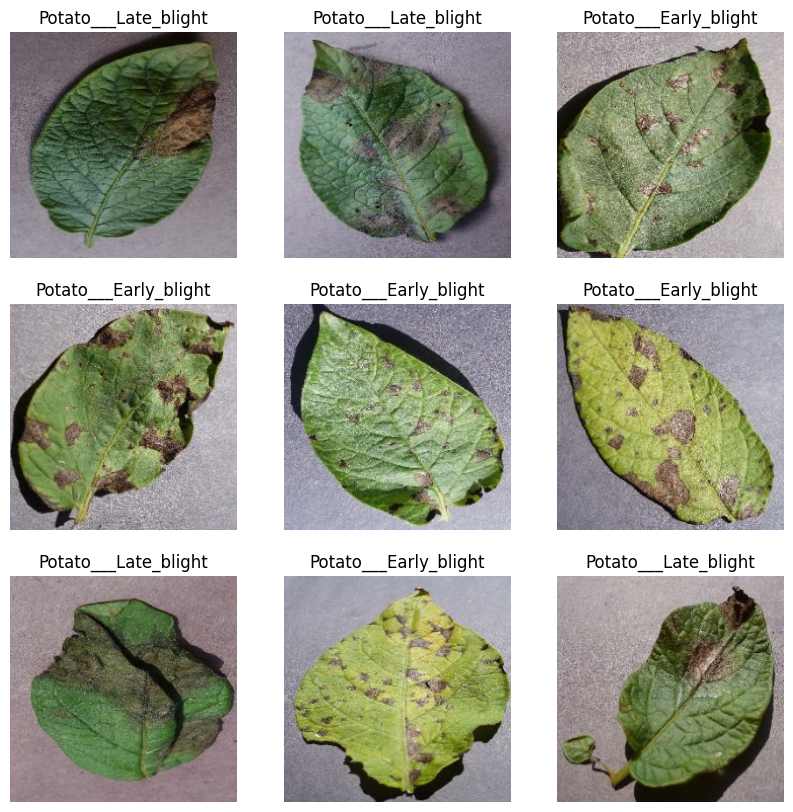

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Cell 13: Optimasi Performa Pipeline Data

Cell ini mengoptimasi pipeline pembacaan data agar proses pelatihan model menjadi lebih cepat dan efisien.

- **`AUTOTUNE = tf.data.AUTOTUNE`** → Konstanta khusus TensorFlow yang memungkinkan framework secara otomatis menentukan jumlah thread/buffer optimal untuk pembacaan data.
- **`train_ds.cache()`** → Menyimpan data ke cache (memori atau disk) sehingga data tidak perlu dibaca ulang dari disk di setiap epoch. Sangat berguna ketika data sudah cukup kecil untuk dimuat ke RAM.
- **`.shuffle(1000)`** → Mengacak urutan data dengan buffer size 1000. Pengacakan penting agar model tidak belajar pola berdasarkan urutan data.
- **`.prefetch(buffer_size=AUTOTUNE)`** → Memuat batch berikutnya di background selagi model sedang melatih batch saat ini (pipeline paralel), mengurangi waktu tunggu (I/O bottleneck).
- **`val_ds.cache().prefetch(...)`** → Dataset validasi hanya perlu di-cache dan prefetch (tidak perlu di-shuffle karena urutan validasi tidak berpengaruh ke performa model).

> Kombinasi `cache + shuffle + prefetch` adalah best practice dalam pipeline data TensorFlow untuk mempercepat pelatihan secara signifikan.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Cell 14: Membangun Arsitektur Model CNN

Cell ini mendefinisikan arsitektur model **Convolutional Neural Network (CNN)** yang akan digunakan untuk klasifikasi penyakit daun kentang.

- **`num_classes = len(class_names)`** → Mendapatkan jumlah kelas output (3 kelas: Early Blight, Late Blight, Healthy).
- **`keras.Sequential([...])`** → Membangun model secara berurutan (layer demi layer).

**Penjelasan setiap layer:**

| Layer | Parameter | Fungsi |
|---|---|---|
| `Rescaling(1./255)` | input_shape=(224,224,3) | Menormalisasi nilai piksel dari rentang [0, 255] ke [0, 1] agar training lebih stabil |
| `Conv2D(32, 3, relu)` | 32 filter, kernel 3×3 | Mengekstrak fitur tingkat rendah (tepi, tekstur) dari gambar |
| `MaxPooling2D()` | - | Mereduksi dimensi spasial (downsampling) sambil mempertahankan fitur penting |
| `Conv2D(64, 3, relu)` | 64 filter, kernel 3×3 | Mengekstrak fitur tingkat menengah (pola lebih kompleks) |
| `MaxPooling2D()` | - | Downsampling kedua |
| `Conv2D(128, 3, relu)` | 128 filter, kernel 3×3 | Mengekstrak fitur tingkat tinggi (representasi abstrak) |
| `MaxPooling2D()` | - | Downsampling ketiga |
| `Flatten()` | - | Mengubah feature map 3D menjadi vektor 1D untuk masuk ke Dense layer |
| `Dense(128, relu)` | 128 neuron | Fully connected layer untuk belajar kombinasi fitur |
| `Dropout(0.5)` | 50% | Mencegah overfitting dengan mematikan 50% neuron secara acak saat training |
| `Dense(num_classes, softmax)` | 3 neuron | Layer output dengan softmax untuk menghasilkan probabilitas per kelas |

> Softmax memastikan jumlah probabilitas semua kelas = 1, sehingga kita bisa mengambil kelas dengan probabilitas tertinggi sebagai prediksi.

In [ ]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Cell 15: Kompilasi Model

Cell ini mengkompilasi model dengan menentukan optimizer, fungsi loss, dan metrik evaluasi.

- **`optimizer="adam"`** → Algoritma optimasi **Adam (Adaptive Moment Estimation)** yang adaptif dan efisien. Adam menggabungkan keunggulan AdaGrad dan RMSProp untuk menyesuaikan learning rate secara otomatis per parameter.
- **`loss="sparse_categorical_crossentropy"`** → Fungsi loss untuk masalah klasifikasi multi-kelas:
  - **Sparse** → Label dalam format integer (0, 1, 2), bukan one-hot encoding
  - **Categorical Crossentropy** → Mengukur perbedaan antara distribusi probabilitas prediksi dan label sebenarnya
- **`metrics=["accuracy"]`** → Metrik yang dipantau selama pelatihan dan validasi. Accuracy mengukur persentase prediksi yang benar.


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Cell 16: Ringkasan Arsitektur Model

Cell ini menampilkan ringkasan lengkap dari arsitektur model CNN yang telah dibangun.

- **`model.summary()`** → Menampilkan tabel yang berisi:
  - Nama setiap layer
  - Tipe layer (Conv2D, MaxPooling2D, Dense, dll.)
  - Output shape dari setiap layer (dimensi tensor setelah melewati layer tersebut)
  - Jumlah parameter yang dapat dilatih (trainable parameters) di setiap layer
  - Total parameter keseluruhan model

> Informasi ini sangat berguna untuk:
> - Memverifikasi bahwa arsitektur sudah sesuai rancangan
> - Mengetahui ukuran model (jumlah parameter)
> - Memahami aliran data dari input hingga output
>
> Total parameter yang besar mengindikasikan model yang kompleks, yang memerlukan lebih banyak data dan waktu pelatihan.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 17: Melatih Model (Training)

Cell ini menjalankan proses pelatihan model CNN pada dataset pelatihan.

- **`epochs = 10`** → Model akan melewati seluruh dataset pelatihan sebanyak **10 kali (epoch)**. Satu epoch = satu kali iterasi penuh melalui semua data training.
- **`model.fit(...)`** → Fungsi utama untuk melatih model:
  - `train_ds` → Data pelatihan yang digunakan untuk memperbarui bobot model
  - `validation_data=val_ds` → Data validasi untuk mengevaluasi performa model di setiap akhir epoch (tidak digunakan untuk memperbarui bobot)
  - `epochs=epochs` → Jumlah epoch pelatihan
- **`history`** → Objek yang menyimpan catatan metrik selama pelatihan (accuracy dan loss untuk training maupun validation di setiap epoch).

> Selama pelatihan, kita akan melihat progress seperti:
> - `loss` dan `accuracy` pada data training
> - `val_loss` dan `val_accuracy` pada data validasi
>
> Jika `val_loss` mulai naik sementara `loss` terus turun, itu merupakan tanda **overfitting**.

In [ ]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.6013 - loss: 1.0900 - val_accuracy: 0.7674 - val_loss: 0.6493
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8322 - loss: 0.4818 - val_accuracy: 0.8256 - val_loss: 0.4376
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8613 - loss: 0.3767 - val_accuracy: 0.8721 - val_loss: 0.3516
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8991 - loss: 0.2890 - val_accuracy: 0.8953 - val_loss: 0.2963
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9114 - loss: 0.2459 - val_accuracy: 0.9128 - val_loss: 0.2509
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9339 - loss: 0.1915 - val_accuracy: 0.9157 - val_loss: 0.2265
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9426 - loss: 0.1429 - val_accuracy: 0.8924 - val_loss: 0.2820
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9499 - loss: 0.1369 - val_accuracy: 0.9331 - val_l

## Cell 18: Visualisasi Kurva Akurasi dan Loss

Cell ini memvisualisasikan perkembangan performa model selama proses pelatihan dalam bentuk grafik.

**Ekstrak data dari history:**
- **`history.history["accuracy"]`** → Daftar nilai akurasi training per epoch
- **`history.history["val_accuracy"]`** → Daftar nilai akurasi validasi per epoch
- **`history.history["loss"]`** → Daftar nilai loss training per epoch
- **`history.history["val_loss"]`** → Daftar nilai loss validasi per epoch

**Grafik 1 - Training and Validation Accuracy:**
- Menampilkan perbandingan akurasi training vs validasi
- Akurasi yang baik menunjukkan kurva training dan validasi yang konvergen ke nilai tinggi
- Gap besar antara training dan validasi mengindikasikan overfitting

**Grafik 2 - Training and Validation Loss:**
- Menampilkan perbandingan loss training vs validasi
- Loss yang baik menunjukkan kedua kurva turun dan konvergen
- Jika `val_loss` mulai naik, model mulai overfitting

> Kedua grafik ini adalah alat diagnostik penting untuk memahami apakah model belajar dengan baik, underfitting, atau overfitting.

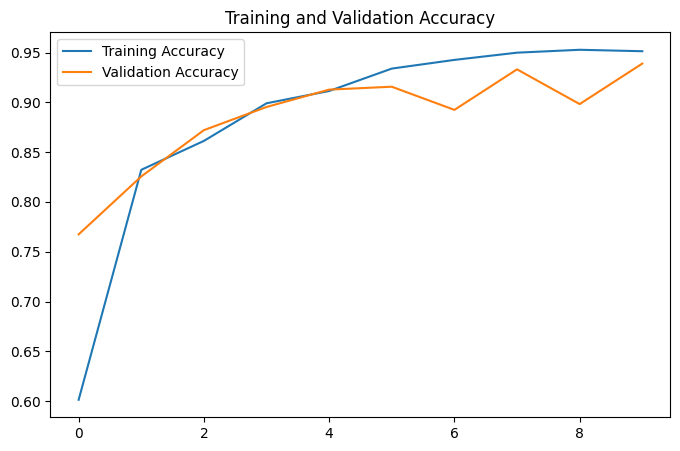

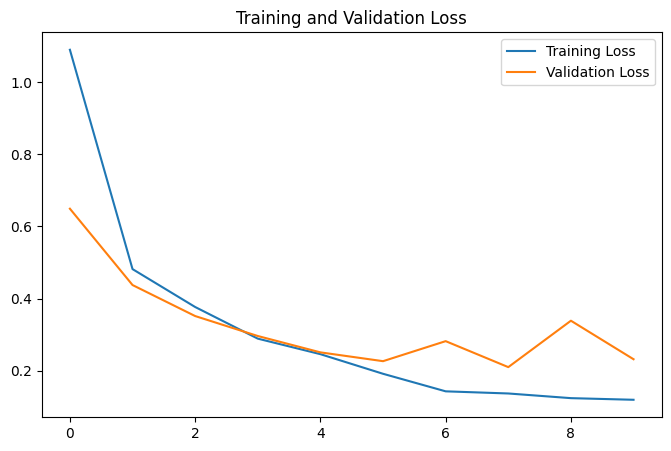

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(epochs)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

## Cell 19: Evaluasi Model pada Data Validasi

Cell ini mengevaluasi performa akhir model pada dataset validasi menggunakan metrik akurasi dan loss.

- **`model.evaluate(val_ds)`** → Menjalankan forward pass pada seluruh data validasi tanpa memperbarui bobot model, lalu menghitung metrik yang telah dikonfigurasi saat kompilasi.
  - Mengembalikan tuple `(val_loss, val_accuracy)`
- **`val_loss`** → Nilai loss pada data validasi. Semakin rendah, semakin baik.
- **`val_accuracy`** → Nilai akurasi pada data validasi. Menunjukkan persentase prediksi yang benar.

> Hasil dari cell ini (Validation Accuracy: **93.9%**, Validation Loss: **0.2319**) menunjukkan bahwa model memiliki kemampuan generalisasi yang baik pada data yang belum pernah dilihat selama pelatihan.

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 570ms/step - accuracy: 0.9390 - loss: 0.2319
Validation Accuracy: 0.9389534592628479
Validation Loss: 0.23188622295856476


## Cell 20: Classification Report dan Confusion Matrix (Data)

Cell ini menghasilkan Classification Report dan Confusion Matrix untuk evaluasi performa model secara detail per kelas.

**Pengumpulan prediksi:**
- **`y_true = []`, `y_pred = []`** → List kosong untuk menyimpan label sebenarnya dan label prediksi.
- **`for images, labels in val_ds`** → Iterasi melalui seluruh batch data validasi.
- **`model.predict(images)`** → Menghasilkan array probabilitas untuk setiap kelas (shape: [batch_size, num_classes]).
- **`np.argmax(predictions, axis=1)`** → Mengambil indeks kelas dengan probabilitas tertinggi sebagai prediksi akhir.
- **`y_true.extend(labels.numpy())`** → Menambahkan label asli ke list.
- **`y_pred.extend(predicted_labels)`** → Menambahkan label prediksi ke list.

**Classification Report:**
- Menampilkan metrik per kelas: **Precision, Recall, F1-Score, Support**
  - **Precision** → Dari semua prediksi positif, berapa yang benar?
  - **Recall** → Dari semua data positif aktual, berapa yang berhasil diprediksi benar?
  - **F1-Score** → Rata-rata harmonik dari Precision dan Recall
  - **Support** → Jumlah sampel aktual per kelas

**Confusion Matrix:**
- Matriks N×N (N = jumlah kelas) yang menunjukkan berapa banyak sampel dari kelas X diprediksi sebagai kelas Y.

> Kelas `Potato___healthy` memiliki recall rendah (**0.43**) akibat jumlah data yang sedikit (class imbalance). Hanya 10 dari 23 sampel *healthy* pada data validasi yang berhasil diprediksi dengan benar.

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 890ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.99      0.95      0.97       148
 Potato___Late_blight       0.90      0.99      0.95       173
     Potato___healthy       1.00      0.43      0.61        23

             accuracy                           0.94       344
            macro avg       0.96      0.79      0.84       344
         weighted avg       0.94      0.94      0.93       344

Confusion Matrix:
[[141   7   0]
 [  1 172   0]
 [  1  12  10]]


## Cell 21: Visualisasi Confusion Matrix (Heatmap)

Cell ini menampilkan Confusion Matrix dalam bentuk heatmap yang lebih mudah dibaca secara visual.

- **`import seaborn as sns`** → Library visualisasi statistik berbasis Matplotlib yang menyediakan fungsi heatmap yang indah.
- **`confusion_matrix(y_true, y_pred)`** → Membuat matriks konfusi dari label sebenarnya (`y_true`) dan label prediksi (`y_pred`).
- **`sns.heatmap(...)`** → Menampilkan matriks sebagai heatmap dengan parameter:
  - `annot=True` → Menampilkan nilai numerik di setiap sel
  - `fmt="d"` → Format integer (bukan desimal)
  - `xticklabels=class_names` → Label sumbu X (kelas prediksi)
  - `yticklabels=class_names` → Label sumbu Y (kelas aktual)
- **`plt.xlabel("Predicted Label")`** → Label sumbu X
- **`plt.ylabel("True Label")`** → Label sumbu Y

**Cara membaca Confusion Matrix:**
- **Diagonal utama** (kiri atas → kanan bawah) → Prediksi benar
- **Di luar diagonal** → Kesalahan prediksi (misklasifikasi)

> Dari visualisasi ini terlihat bahwa sebagian gambar `Potato___healthy` salah diklasifikasikan sebagai `Potato___Late_blight` akibat kurangnya data kelas sehat.

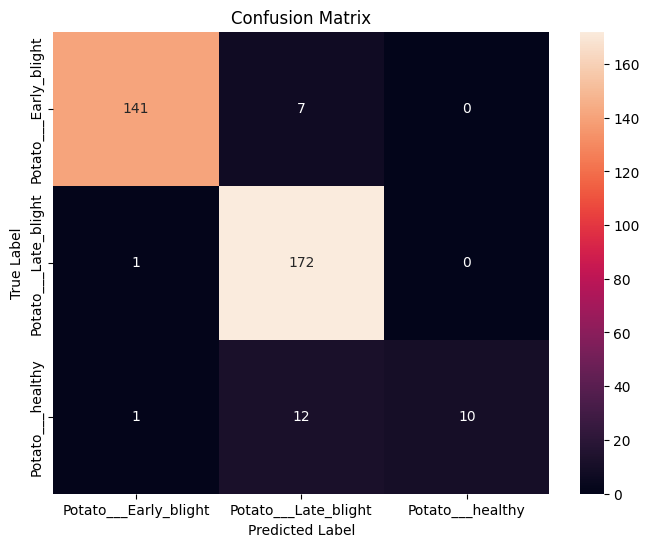

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Cell 22: Visualisasi Prediksi pada Data Validasi

Cell ini menampilkan 9 contoh gambar dari data validasi beserta label aktual dan prediksi model untuk evaluasi visual.

- **`val_ds.take(1)`** → Mengambil 1 batch gambar dari dataset validasi.
- **`model.predict(images)`** → Menghasilkan probabilitas prediksi untuk setiap gambar.
- **`np.argmax(predictions, axis=1)`** → Mengambil kelas dengan probabilitas tertinggi sebagai prediksi akhir.
- **`plt.subplot(3, 3, i + 1)`** → Membuat grid tampilan 3×3.
- **`images[i].numpy().astype("uint8")`** → Mengonversi gambar ke format yang bisa ditampilkan Matplotlib.
- **`actual_label`** → Label kelas yang sebenarnya (ground truth).
- **`predicted_label`** → Label hasil prediksi model.
- **`plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")`** → Menampilkan kedua label sebagai judul gambar.

> Gambar yang diprediksi **benar** akan memiliki `Actual` dan `Predicted` yang sama.
> Gambar yang diprediksi **salah** akan memiliki label yang berbeda, membantu identifikasi pola kesalahan model secara visual.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step


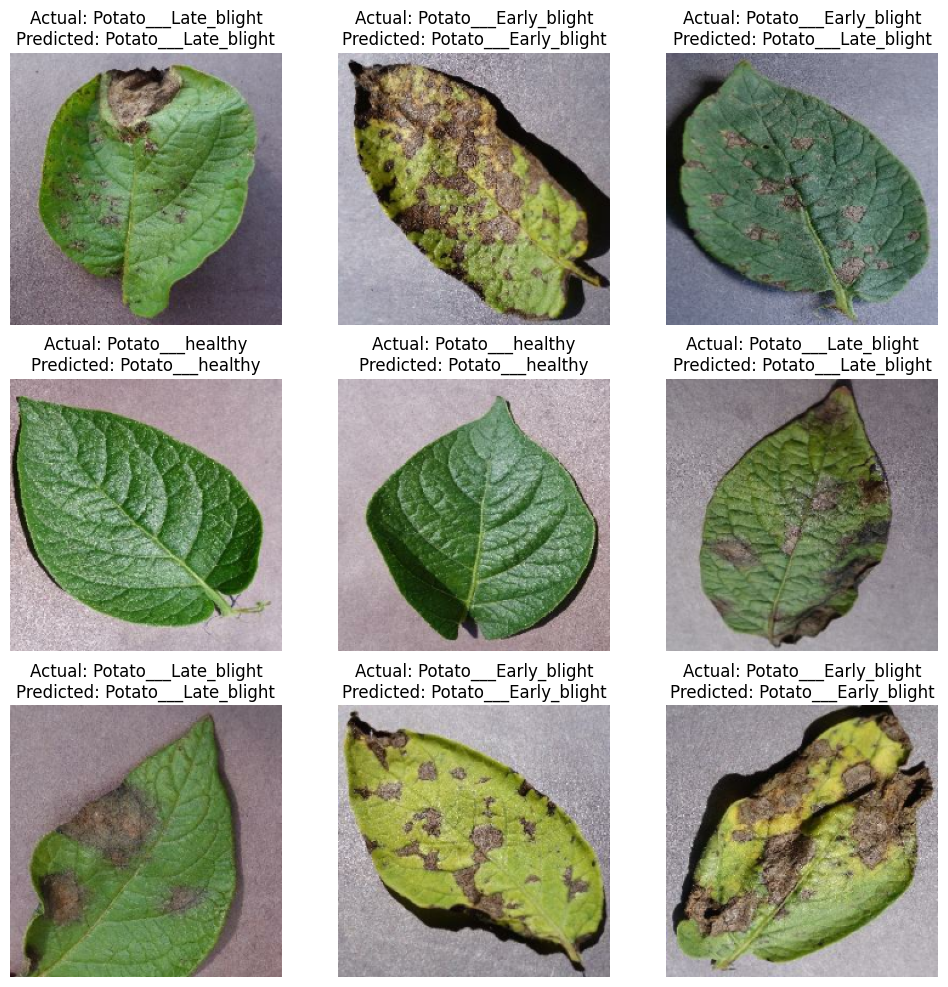

In [ ]:
plt.figure(figsize=(12, 12))

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        actual_label = class_names[labels[i]]
        predicted_label = class_names[predicted_labels[i]]

        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
        plt.axis("off")

## Cell 23: Menyimpan Model

Cell ini menyimpan model yang telah dilatih ke dalam file agar bisa digunakan kembali tanpa perlu melatih ulang.

- **`model.save("plant_disease_cnn_model.keras")`** → Menyimpan seluruh model (arsitektur + bobot + konfigurasi kompilasi) ke dalam file berformat **Keras native format** (`.keras`).

**Kelebihan format `.keras`:**
- Menyimpan semua informasi yang diperlukan (arsitektur, bobot, optimizer state)
- Lebih aman dan portable dibanding format lama (`.h5`)
- Bisa dimuat kembali dengan `tf.keras.models.load_model("plant_disease_cnn_model.keras")`

> File model disimpan di direktori kerja Google Colab (`/content/`). Untuk menggunakan model di luar Colab, unduh file tersebut ke komputer lokal.
>
> Model yang tersimpan dapat langsung digunakan untuk inferensi (prediksi) tanpa perlu proses pelatihan ulang.

In [ ]:
model.save("plant_disease_cnn_model.keras")

##Cell 24: Upload Gambar untuk Prediksi (Uji Coba 1)

Cell ini memungkinkan pengguna untuk mengunggah gambar daun kentang dari komputer lokal ke Google Colab untuk diprediksi oleh model.

- **`from google.colab import files`** → Mengimpor modul `files` khusus Google Colab yang menyediakan fungsi upload/download file.
- **`files.upload()`** → Menampilkan tombol interaktif "Choose Files" di output cell untuk memilih dan mengunggah file dari komputer. Mengembalikan dictionary `{nama_file: konten_binary}`.
- **`uploaded`** → Variabel yang menyimpan file yang telah diunggah dalam format dictionary.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_healthy.jpg to test_healthy.jpg


## Cell 25: Prediksi Gambar yang Diunggah (Uji Coba 1)

Cell ini memproses gambar yang telah diunggah dan menghasilkan prediksi kelas penyakit beserta tingkat kepercayaan (confidence) dari model.

- **`list(uploaded.keys())[0]`** → Mengambil nama file pertama dari dictionary uploaded.
- **`load_img(uploaded_file_name, target_size=(224, 224))`** → Memuat gambar dan meresize ke ukuran 224×224 piksel (sesuai input model).
- **`img_to_array(img)`** → Mengonversi objek gambar PIL ke array NumPy dengan shape (224, 224, 3).
- **`tf.expand_dims(img_array, 0)`** → Menambahkan dimensi batch di depan sehingga shape menjadi (1, 224, 224, 3). Model memerlukan input dalam format batch.
- **`model.predict(img_array)`** → Menghasilkan probabilitas prediksi untuk setiap kelas (shape: [1, 3]).
- **`np.argmax(predictions[0])`** → Mengambil indeks kelas dengan probabilitas tertinggi.
- **`class_names[...]`** → Mengonversi indeks ke nama kelas.
- **`100 * np.max(predictions[0])`** → Menghitung confidence dalam persentase (probabilitas tertinggi × 100).
- **`plt.imshow(img)`** → Menampilkan gambar asli.
- **`plt.title(f"Prediksi: {predicted_class}\nConfidence: {confidence:.2f}%")`** → Menampilkan hasil prediksi dan confidence sebagai judul.

> Confidence yang tinggi (>80%) menandakan model yakin dengan prediksinya. Confidence rendah bisa disebabkan gambar yang buram, sudut pengambilan yang tidak biasa, atau gambar bukan daun kentang.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


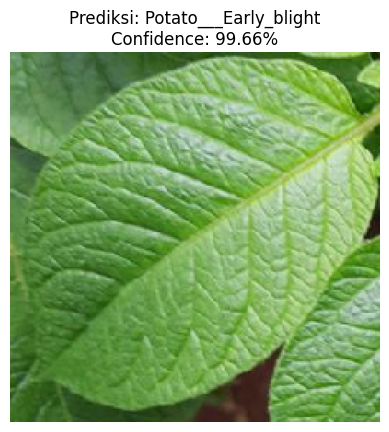

Prediksi: Potato___Early_blight
Confidence: 99.658165


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

uploaded_file_name = list(uploaded.keys())[0]

img = load_img(uploaded_file_name, target_size=(img_height, img_width))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

predicted_class = class_names[np.argmax(predictions[0])]
confidence = 100 * np.max(predictions[0])

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Prediksi:", predicted_class)
print("Confidence:", confidence)

## Cell 26: Upload Gambar untuk Prediksi (Uji Coba 2)

Cell ini identik dengan Cell 24 (Upload Gambar Uji Coba 1) — digunakan untuk mengunggah gambar kedua guna melakukan uji prediksi tambahan.

- **`files.upload()`** → Menampilkan kembali tombol upload untuk memilih gambar daun kentang kedua dari komputer lokal.

> Pengujian dengan beberapa gambar berbeda membantu memverifikasi konsistensi dan keandalan model dalam berbagai kondisi gambar (pencahayaan, sudut, latar belakang).

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_early.jpg to test_early.jpg


## Cell 27: Prediksi Gambar yang Diunggah (Uji Coba 2)

Cell ini identik dengan Cell 25 (Prediksi Uji Coba 1) — memproses dan memprediksi gambar kedua yang diunggah.

**Alur proses sama dengan prediksi pertama:**
1. Ambil nama file dari dictionary `uploaded`
2. Muat dan resize gambar ke 224×224
3. Konversi ke array dan tambahkan dimensi batch
4. Jalankan prediksi dengan `model.predict()`
5. Ambil kelas dengan probabilitas tertinggi
6. Hitung confidence score
7. Tampilkan gambar beserta hasil prediksi

> Pengujian dengan gambar kedua memastikan model tidak hanya bekerja untuk satu kasus spesifik, melainkan dapat menggeneralisasi dengan baik pada berbagai input.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


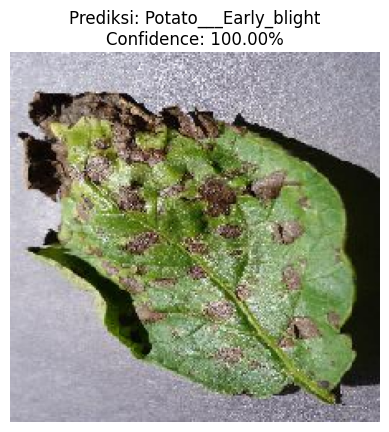

Prediksi: Potato___Early_blight
Confidence: 100.0


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

uploaded_file_name = list(uploaded.keys())[0]

img = load_img(uploaded_file_name, target_size=(img_height, img_width))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

predicted_class = class_names[np.argmax(predictions[0])]
confidence = 100 * np.max(predictions[0])

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Prediksi:", predicted_class)
print("Confidence:", confidence)

## Cell 28: Upload Gambar untuk Prediksi (Uji Coba 3)

Cell ini digunakan untuk mengunggah gambar ketiga guna melakukan uji prediksi tambahan.

- **`files.upload()`** → Menampilkan tombol upload untuk memilih gambar daun kentang ketiga dari komputer lokal.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_late.jpg to test_late.jpg


## Cell 29: Prediksi Gambar yang Diunggah (Uji Coba 3)

Cell ini memproses dan memprediksi gambar ketiga yang telah diunggah — merupakan uji coba terakhir dalam notebook ini.

**Alur proses sama dengan prediksi sebelumnya:**
1. Ambil nama file dari dictionary `uploaded`
2. Muat dan resize gambar ke 224×224 piksel
3. Konversi ke array NumPy dan tambahkan dimensi batch (1, 224, 224, 3)
4. Jalankan prediksi dengan `model.predict()`
5. Identifikasi kelas dengan probabilitas tertinggi
6. Hitung persentase confidence
7. Tampilkan gambar beserta label prediksi dan confidence

> Setelah menjalankan ketiga uji coba ini, kita dapat mengevaluasi performa model secara kualitatif pada gambar-gambar nyata yang belum pernah dilihat model sebelumnya.
>
> Model yang telah dilatih mampu mengklasifikasikan kondisi daun kentang ke dalam tiga kategori:
> - **Potato___Early_blight** → Penyakit bercak daun awal (Alternaria solani)
> - **Potato___Late_blight** → Penyakit bercak daun lanjut (Phytophthora infestans)  
> - **Potato___healthy** → Daun kentang sehat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


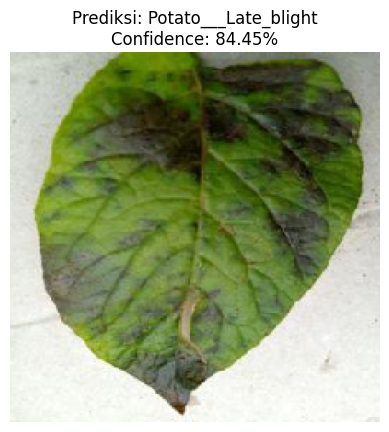

Prediksi: Potato___Late_blight
Confidence: 84.447914


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

uploaded_file_name = list(uploaded.keys())[0]

img = load_img(uploaded_file_name, target_size=(img_height, img_width))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

predicted_class = class_names[np.argmax(predictions[0])]
confidence = 100 * np.max(predictions[0])

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Prediksi:", predicted_class)
print("Confidence:", confidence)

## Cell 30: Ekstraksi Fitur untuk Model Tradisional (SVM & Random Forest)

Cell ini mengekstrak fitur dari setiap gambar dalam dataset agar dapat digunakan oleh algoritma machine learning tradisional seperti SVM dan Random Forest, yang tidak bisa memproses tensor gambar secara langsung.

- **`extract_features_and_labels(dataset)`** → Fungsi kustom yang menerima TensorFlow dataset dan mengembalikan array fitur beserta labelnya.
- **`tf.image.rgb_to_grayscale(img)`** → Mengonversi gambar dari 3 channel warna (RGB) menjadi 1 channel abu-abu (grayscale), mereduksi dimensi dari (224, 224, 3) → (224, 224, 1).
- **`tf.reshape(img_gray, [-1])`** → Meratakan (flatten) gambar menjadi vektor 1D dengan panjang 224 × 224 = **50.176** elemen. Ini adalah representasi fitur piksel mentah.
- **`X_train_raw, y_train_raw`** → Fitur dan label untuk data training (1377 sampel).
- **`X_val, y_val`** → Fitur dan label untuk data validasi (344 sampel).

> **Output:** Dua array dengan shape `(1377, 50176)` dan `(344, 50176)`, menunjukkan bahwa setiap gambar direpresentasikan sebagai vektor 50.176 dimensi. Pendekatan ini lebih sederhana dibanding CNN namun kehilangan informasi spasial dari gambar.


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf

def extract_features_and_labels(dataset):
    features = []
    labels = []
    for images, imgs_labels in dataset:
        for img, label in zip(images, imgs_labels):
            img_gray = tf.image.rgb_to_grayscale(img)
            flattened = tf.reshape(img_gray, [-1]).numpy()
            features.append(flattened)
            labels.append(label.numpy())
    return np.array(features), np.array(labels)

print("Proses ekstraksi..." )
X_train_raw, y_train_raw = extract_features_and_labels(train_ds)
X_val, y_val = extract_features_and_labels(val_ds)

print("Sukses:")
print(X_train_raw.shape, X_val.shape)

Proses ekstraksi...
Sukses:
(1377, 50176) (344, 50176)


## Cell 31: Pelatihan Skenario 1 – SVM dan Random Forest (Tanpa Penanganan Class Imbalance)

Cell ini melatih dua model machine learning tradisional pada fitur piksel mentah (grayscale flatten) **tanpa** penanganan ketidakseimbangan kelas.

**Support Vector Machine (SVM):**
- **`SVC(kernel='rbf', C=1.0, random_state=42)`** → Model SVM dengan kernel Radial Basis Function (RBF). Parameter `C=1.0` mengontrol trade-off antara margin dan kesalahan klasifikasi.

**Random Forest:**
- **`RandomForestClassifier(n_estimators=100, random_state=42)`** → Ensemble 100 pohon keputusan yang bekerja secara paralel dan menggabungkan prediksi via majority voting.

**Hasil Skenario 1:**

| Model | Accuracy | Catatan |
|---|---|---|
| SVM | 89% | Kelas `Potato___healthy` precision & recall = 0.00 |
| Random Forest | 87% | Kelas `Potato___healthy` precision & recall = 0.00 |

(Catatan: Nilai metrik pada tabel di bawah ini telah dibulatkan ke dua angka desimal)

> Tanpa penanganan class imbalance, kedua model **gagal total** mengklasifikasikan kelas `Potato___healthy` (precision & recall = 0.00) karena kelas ini hanya memiliki 121 sampel dibanding 800 untuk dua kelas lainnya. Model cenderung mengabaikan kelas minoritas.


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("=== SKENARIO 1 ===")

svm_skenario1 = SVC(kernel='rbf', C=1.0, random_state=42)
svm_skenario1.fit(X_train_raw, y_train_raw)
y_pred_svm1 = svm_skenario1.predict(X_val)
acc_svm1 = accuracy_score(y_val, y_pred_svm1)

rf_skenario1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_skenario1.fit(X_train_raw, y_train_raw)
y_pred_rf1 = rf_skenario1.predict(X_val)
acc_rf1 = accuracy_score(y_val, y_pred_rf1)

print("Hasil SVM Skenario 1:")
print(classification_report(y_val, y_pred_svm1, target_names=class_names))

print("Hasil Random Forest Skenario 1:")
print(classification_report(y_val, y_pred_rf1, target_names=class_names))

=== SKENARIO 1 ===
Hasil SVM Skenario 1:
                       precision    recall  f1-score   support

Potato___Early_blight       0.92      0.97      0.94       148
 Potato___Late_blight       0.87      0.94      0.90       173
     Potato___healthy       0.00      0.00      0.00        23

             accuracy                           0.89       344
            macro avg       0.59      0.64      0.61       344
         weighted avg       0.83      0.89      0.86       344

Hasil Random Forest Skenario 1:
                       precision    recall  f1-score   support

Potato___Early_blight       0.86      0.95      0.90       148
 Potato___Late_blight       0.87      0.91      0.89       173
     Potato___healthy       0.00      0.00      0.00        23

             accuracy                           0.87       344
            macro avg       0.58      0.62      0.60       344
         weighted avg       0.81      0.87      0.84       344



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## Cell 32: Pelatihan Skenario 2 – SVM dan Random Forest (Dengan `class_weight='balanced'`)

Cell ini melatih ulang model SVM dan Random Forest dengan penambahan parameter `class_weight='balanced'` untuk mengatasi masalah ketidakseimbangan kelas (*class imbalance*) yang terjadi pada Skenario 1.

- **`class_weight='balanced'`** → Parameter ini menginstruksikan model untuk secara otomatis menyesuaikan bobot setiap kelas berbanding terbalik dengan frekuensinya. Kelas yang lebih sedikit sampelnya (seperti `Potato___healthy` dengan 121 gambar) akan mendapat bobot lebih tinggi dalam proses pelatihan.
  - Formula bobot: `n_samples / (n_classes × n_samples_per_class)`
  - Kelas dengan sedikit sampel → bobot tinggi → model lebih "memperhatikan" kelas ini

**Hasil Skenario 2:**

| Model | Accuracy | Healthy Precision | Healthy Recall |
|---|---|---|---|
| SVM | 90% | 0.52 | 0.48 |
| Random Forest | 88% | 1.00 | 0.04 |

(Catatan: Nilai metrik pada tabel di bawah ini telah dibulatkan ke dua angka desimal)

> Dengan `class_weight='balanced'`, SVM berhasil mulai mengenali kelas `Potato___healthy` (recall meningkat dari 0.00 → 0.48). Random Forest memiliki precision sempurna (1.00) namun recall sangat rendah (0.04), artinya sangat konservatif dalam memprediksi kelas *healthy*.


In [ ]:
print("=== SKENARIO 2 ===")

svm_skenario2 = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
svm_skenario2.fit(X_train_raw, y_train_raw)
y_pred_svm2 = svm_skenario2.predict(X_val)
acc_svm2 = accuracy_score(y_val, y_pred_svm2)

rf_skenario2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_skenario2.fit(X_train_raw, y_train_raw)
y_pred_rf2 = rf_skenario2.predict(X_val)
acc_rf2 = accuracy_score(y_val, y_pred_rf2)

print("Hasil SVM Skenario 2:")
print(classification_report(y_val, y_pred_svm2, target_names=class_names))

print("Hasil Random Forest Skenario 2:")
print(classification_report(y_val, y_pred_rf2, target_names=class_names))

=== SKENARIO 2 ===
Hasil SVM Skenario 2:
                       precision    recall  f1-score   support

Potato___Early_blight       0.92      0.97      0.95       148
 Potato___Late_blight       0.92      0.88      0.90       173
     Potato___healthy       0.52      0.48      0.50        23

             accuracy                           0.90       344
            macro avg       0.79      0.78      0.78       344
         weighted avg       0.89      0.90      0.89       344

Hasil Random Forest Skenario 2:
                       precision    recall  f1-score   support

Potato___Early_blight       0.88      0.95      0.92       148
 Potato___Late_blight       0.88      0.93      0.90       173
     Potato___healthy       1.00      0.04      0.08        23

             accuracy                           0.88       344
            macro avg       0.92      0.64      0.63       344
         weighted avg       0.89      0.88      0.85       344



## Cell 33: Visualisasi Perbandingan Akurasi Semua Model

Cell ini membuat grafik batang (*bar chart*) yang membandingkan akurasi validasi dari seluruh model yang telah diuji: CNN, SVM (dua skenario), dan Random Forest (dua skenario).

- **`acc_cnn = 0.939`** → Nilai akurasi CNN yang telah diperoleh dari hasil pelatihan sebelumnya (Cell 19), dimasukkan secara manual.
- **`acc_svm1, acc_rf1`** → Akurasi SVM dan Random Forest Skenario 1 (tanpa class_weight).
- **`acc_svm2, acc_rf2`** → Akurasi SVM dan Random Forest Skenario 2 (dengan class_weight balanced).
- **`plt.bar(...)`** → Membuat bar chart dengan warna berbeda per kelompok model:
  - Biru → CNN
  - Oranye → Skenario 1 (tanpa penanganan imbalance)
  - Hijau → Skenario 2 (dengan penanganan imbalance)
- **Anotasi persentase** di atas setiap batang memudahkan pembacaan nilai akurasi secara langsung.

**Ringkasan perbandingan akurasi validasi:**

| Model | Akurasi |
|---|---|
| CNN | **93.9%** |
| SVM Skenario 1 | 89.0% |
| Random Forest Skenario 1 | 86.6% |
| SVM Skenario 2 | 89.5% |
| Random Forest Skenario 2 | 88.1% |

> **Kesimpulan:** Model CNN unggul secara signifikan dibanding metode tradisional. Hal ini menunjukkan bahwa arsitektur CNN yang mampu mengekstrak fitur hierarkis secara otomatis jauh lebih efektif untuk tugas klasifikasi gambar dibanding pendekatan fitur piksel mentah pada SVM dan Random Forest.


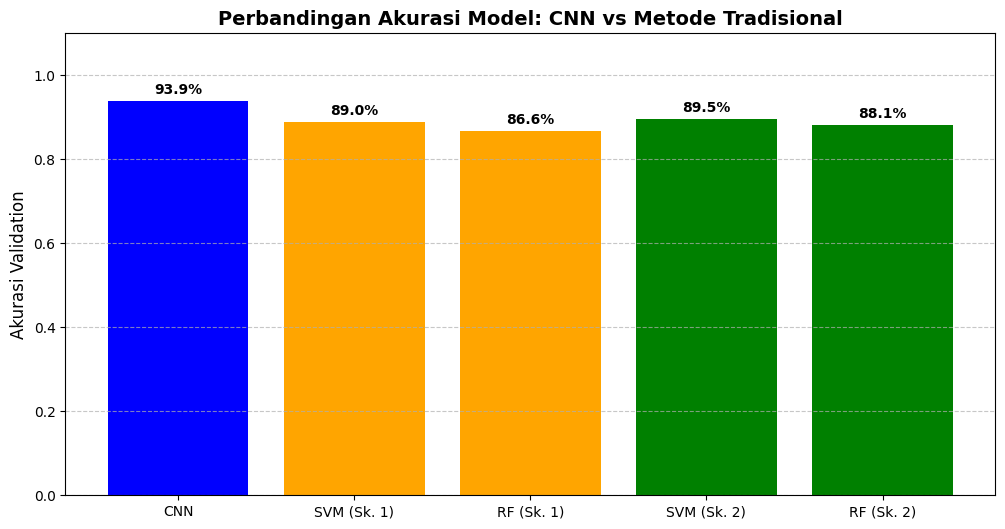

In [ ]:
import matplotlib.pyplot as plt

acc_cnn = 0.939

kategori = [
    'CNN',
    'SVM (Sk. 1)', 'RF (Sk. 1)',
    'SVM (Sk. 2)', 'RF (Sk. 2)'
]
akurasi = [acc_cnn, acc_svm1, acc_rf1, acc_svm2, acc_rf2]

plt.figure(figsize=(12, 6))
bars = plt.bar(kategori, akurasi, color=['blue', 'orange', 'orange', 'green', 'green'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Perbandingan Akurasi Model: CNN vs Metode Tradisional', fontsize=14, fontweight='bold')
plt.ylabel('Akurasi Validation', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()